tensor([[0., 0., 0., 0., 0.],
        [0., 1., 1., 1., 0.],
        [0., 1., 1., 1., 0.],
        [0., 1., 1., 1., 0.],
        [0., 0., 0., 0., 0.]])
torch.Size([5, 5])


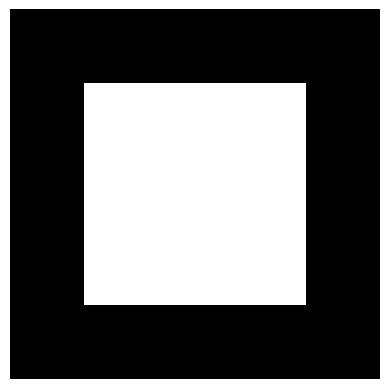

In [1]:
import torch
import matplotlib.pyplot as plt

img = torch.tensor([
    [0., 0., 0., 0., 0.],
    [0., 1., 1., 1., 0.],
    [0., 1., 1., 1., 0.],
    [0., 1., 1., 1., 0.],
    [0., 0., 0., 0., 0.]
])

print(img)
print(img.shape)

plt.imshow(img, cmap="gray")
plt.axis("off");

tensor([[ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        [-1., -1., -1.]])
torch.Size([3, 3])


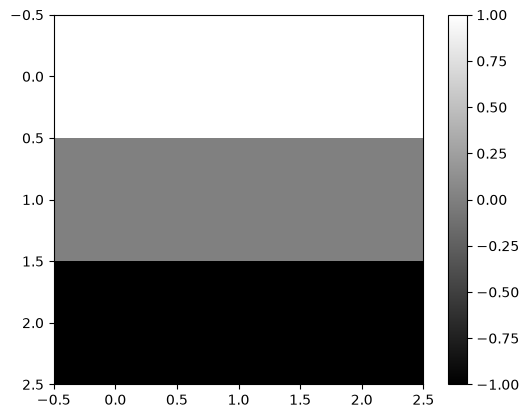

In [2]:
kernel = torch.tensor([
    [1.,  1., 1.],
    [0.,  0., 0.],
    [-1., -1., -1.]
])

print(kernel)
print(kernel.shape)

plt.imshow(kernel, cmap="gray")
plt.colorbar();

In [3]:
patch = img[1:4, 1:4]

print("patch:")
print(patch)

print("\nkernel:")
print(kernel)

result = (patch * kernel).sum()

print("\nresult:", result.item())

patch:
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

kernel:
tensor([[ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        [-1., -1., -1.]])

result: 0.0


In [4]:
patch1 = img[0:3, 0:3]
patch2 = img[0:3, 1:4]

r1 = (patch1 * kernel).sum()
r2 = (patch2 * kernel).sum()

print("patch 1:\n", patch1)
print("result 1:", r1.item())

print("\npatch 2:\n", patch2)
print("result 2:", r2.item())

patch 1:
 tensor([[0., 0., 0.],
        [0., 1., 1.],
        [0., 1., 1.]])
result 1: -2.0

patch 2:
 tensor([[0., 0., 0.],
        [1., 1., 1.],
        [1., 1., 1.]])
result 2: -3.0


tensor([[-2., -3., -2.],
        [ 0.,  0.,  0.],
        [ 2.,  3.,  2.]])


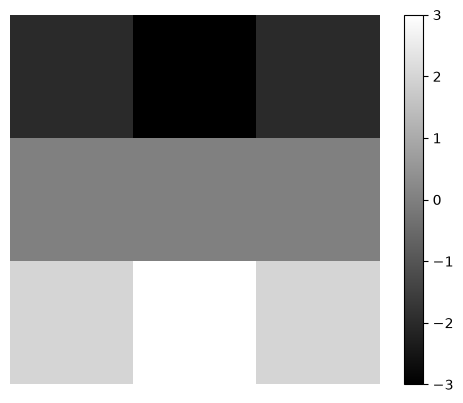

In [5]:
out = torch.zeros(3, 3)

for i in range(3):
    for j in range(3):
        patch = img[i:i+3, j:j+3]
        out[i, j] = (patch * kernel).sum()

print(out)

plt.imshow(out, cmap="gray")
plt.colorbar()
plt.axis("off");

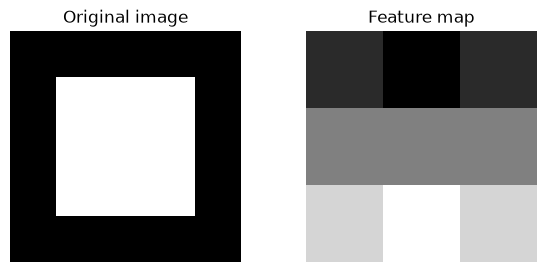

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original image")
ax[0].axis("off")

ax[1].imshow(out, cmap="gray")
ax[1].set_title("Feature map")
ax[1].axis("off")

plt.show()

In [8]:
kernel2 = torch.tensor([
    [ 1., 0., -1.],
    [ 1., 0., -1.],
    [ 1., 0., -1.]
])

out2 = torch.zeros(3, 3)

for i in range(3):
    for j in range(3):
        patch = img[i:i+3, j:j+3]
        out2[i, j] = (patch * kernel2).sum()

print("horizontal detector:\n", out)
print("\nvertical detector:\n", out2)

horizontal detector:
 tensor([[-2., -3., -2.],
        [ 0.,  0.,  0.],
        [ 2.,  3.,  2.]])

vertical detector:
 tensor([[-2.,  0.,  2.],
        [-3.,  0.,  3.],
        [-2.,  0.,  2.]])


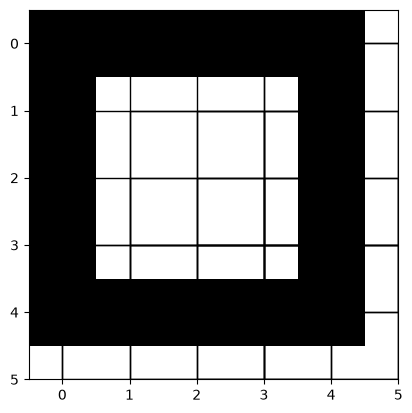

In [9]:
fig, ax = plt.subplots()

ax.imshow(img, cmap="gray")

for i in range(4):
    for j in range(4):
        ax.add_patch(plt.Rectangle((j, i), 3, 3,
                                   fill=False, linewidth=1))

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.grid(False);

In [10]:
kernel = torch.tensor([
    [1.,  1., 1.],
    [0.,  0., 0.],
    [-1., -1., -1.]
])

patch_a = img[0:3, 0:3]
patch_b = img[1:4, 1:4]

score_a = (patch_a * kernel).sum()
score_b = (patch_b * kernel).sum()

print("same kernel:")
print(kernel)
print("\nscore A:", score_a.item())
print("score B:", score_b.item())

same kernel:
tensor([[ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        [-1., -1., -1.]])

score A: -2.0
score B: 0.0


In [12]:
img.unsqueeze(0).unsqueeze(0).shape

torch.Size([1, 1, 5, 5])

In [13]:
import torch.nn as nn

img_batch = img.unsqueeze(0).unsqueeze(0)

conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    bias=False
)

out = conv(img_batch)

print("input :", img_batch.shape)
print("output:", out.shape)
print("kernel:", conv.weight.shape)

input : torch.Size([1, 1, 5, 5])
output: torch.Size([1, 1, 3, 3])
kernel: torch.Size([1, 1, 3, 3])


In [14]:
out

tensor([[[[-0.4503, -0.4517, -0.1466],
          [-0.3421, -0.4999, -0.0535],
          [-0.0075,  0.0423,  0.2616]]]], grad_fn=<ConvolutionBackward0>)

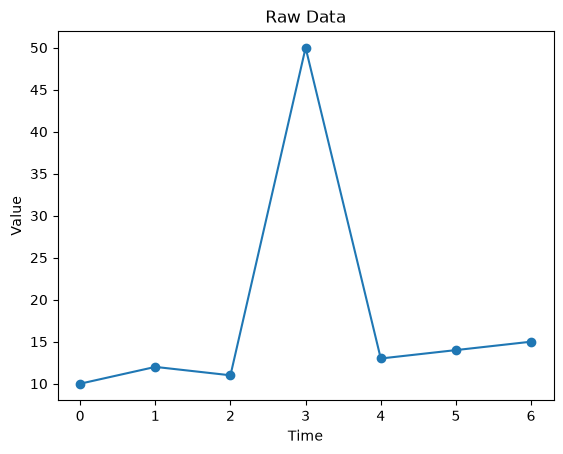

In [15]:
import numpy as np
import matplotlib.pyplot as plt

values = np.array([10, 12, 11, 50, 13, 14, 15])

plt.plot(values, marker="o")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Raw Data")
plt.show()

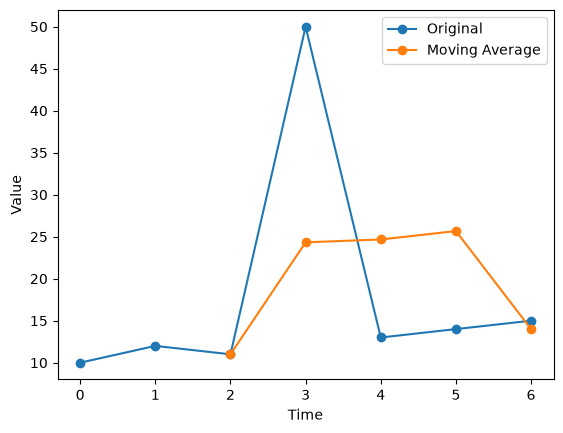

In [16]:
import matplotlib.pyplot as plt

values = [10, 12, 11, 50, 13, 14, 15]
moving_averages = [11.0, 24.33, 24.67, 25.67, 14.0]

plt.plot(values, marker="o", label="Original")
plt.plot(range(2, 7), moving_averages, marker="o", label="Moving Average")

plt.legend()
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

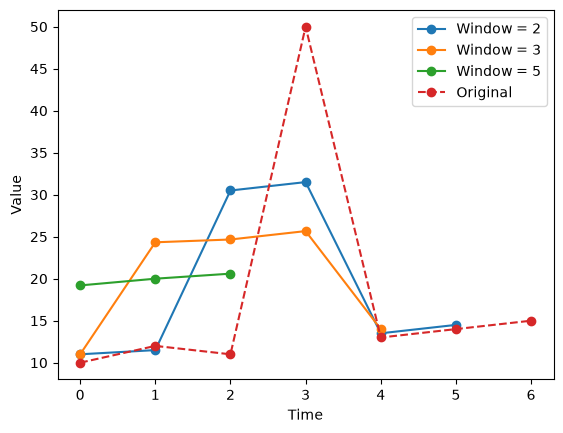

In [17]:
import numpy as np
import matplotlib.pyplot as plt

values = np.array([10, 12, 11, 50, 13, 14, 15])

for window in [2, 3, 5]:
    moving_avg = np.convolve(values, np.ones(window) / window, mode="valid")
    plt.plot(moving_avg, marker="o", label=f"Window = {window}")

plt.plot(values, "o--", label="Original")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()